In [ ]:
from google.colab import drive
import pandas as pd
import os as os
from google.colab import files

drive.mount('/content/dive')


Mounted at /content/dive


In [ ]:
cd /content/dive/MyDrive/csv

/content/dive/MyDrive/csv


In [ ]:
ls

AguaEmbalsada_RioCofio_LaAcena.csv
AguaEmbalsada_RioGuadalix_Pedrezuela.csv
AguaEmbalsada_RioGuadarrama-Aulencia_LaJorosa.csv
AguaEmbalsada_RioGuadarrama-Aulencia_Navalmedio.csv
AguaEmbalsada_RioGuadarrama-Aulencia_Valmayor.csv
AguaEmbalsada_RioJarama_ElVado.csv
AguaEmbalsada_RioLosMorales_LosMorales.csv
AguaEmbalsada_RioLozoya_ElAtazar.csv
AguaEmbalsada_RioLozoya_ElVillar.csv
AguaEmbalsada_RioLozoya_LaPinilla.csv
AguaEmbalsada_RioLozoya_PuentesViejas.csv
AguaEmbalsada_RioLozoya_Riosequillo.csv
AguaEmbalsada_RioManzanares_Navacerrada.csv
AguaEmbalsada_RioManzanares_Santillana.csv


In [ ]:
import os

ruta = "/content/dive/MyDrive/csv"

for archivo in os.listdir(ruta):
    if archivo.lower().endswith(".csv"):
        path_archivo = os.path.join(ruta, archivo)
        with open(path_archivo, "rb") as f:
            for i, line in enumerate(f, 1):
                try:
                    line.decode("utf-8")
                except UnicodeDecodeError:
                    print(f"[ERROR] {archivo}, línea {i} contiene caracteres no UTF-8")



In [104]:
# Importación de librerias necesarias

import os # Manejo de carpetas en bucles etc.
import pandas as pd # Manejo de archivos CSV y unión de cada uno en un Dataframe
from google.colab import files # Opción de descarga del archivo final

# Función que unirá los archivos CSV en un Dataframe una vez limpiados

def generar_dataframe_embalses_completos():
    ruta = "/content/dive/MyDrive/csv" # Definición de ruta archivos CSV
    ruta_descarga = "/content/dive/MyDrive/dataset_embalses_final.csv"
    # Ruta de descarga del CSV final

    # Definición de los meses válidos una vez revisados, todos coinciden
    meses_validos = [
        "enero","febrero","marzo","abril","mayo","junio",
        "julio","agosto","septiembre","octubre","noviembre","diciembre"
    ]


    # Definición de lista donde se guardará cada embalse
    df_list = []

    # Bucle que recorre cada archivo y lo guarda en la lista anterior
    for archivo in os.listdir(ruta):
        if not archivo.lower().endswith(".csv"):
            continue
        try: # Try para limpieza de datos
            embalse = archivo.replace(".csv", "").split("_")[-1] # Eliminación de espacios y barras ba
            df = pd.read_csv(
                os.path.join(ruta, archivo),
                sep=";", # Separación de columnas mediante ;
                encoding="utf-8-sig", # Utilizar compatibilidad de carácteres UTF-8
                engine="python" # Utilizar motor de python
            )

            # Eliminación de espacios y conversión a minúsculas de cada índice de columna
            df.columns = df.columns.str.strip().str.lower()
            # Definición de como deben quedar los índices de las columnas
            columnas_de_interes = ['anio','mes','hec_cub']
            # Verifica si los datos tratados son iguales a las columnas de la linea anterior
            df = df[[c for c in columnas_de_interes if c in df.columns]]

            # Limpiar columnas (Elimina espacios, convierte todo a minúculas y a formato string)
            df['mes'] = df['mes'].astype(str).str.strip().str.lower()
            df['anio'] = pd.to_numeric(df['anio'], errors='coerce')  # años faltantes con valor NaN
            df['hec_cub'] = df['hec_cub'].astype(str).str.strip()    # mantener coma

            # Propagar años hacia abajo por si acaso recibimos otros csv con errores en un futuro
            df['anio'] = df['anio'].ffill()

            # Filtrar meses válidos de nuevo por si recibimos nuevos archivos
            df = df[df['mes'].isin(meses_validos)]

            # Convertir año a formato int
            df['anio'] = df['anio'].astype(int)


            df['embalse'] = embalse # Crear columna embalse
            df_list.append(df) # Añadir datos a la lista para actualizar el dataset si obtenemos nuevos archivos

        # Manejo de errores obtenidos en las operaciones con que intentó Try
        except Exception as e:
            print(f"[ERROR] {archivo}: {e}") # Explica el error y su tipo

    if not df_list: # Si la lista esta vacía porque fallaron operaciones en cada archivo, entonces devuelve none (nada)
        print("No se encontraron datos válidos.") # Aviso de que no hay nada en la lista de embalses (las operaciones con try fallaron)
        return None

    # Concatenar todos los CSV con uso de pandas y .concat
    df_unido = pd.concat(df_list, ignore_index=True) # Concatena y actualiza el índice para el nuevo documento

    # Pivotar valores para que cada valor este en la columna de embalse
    df_pivot = df_unido.pivot_table(
        index=['anio','mes'], # Definición de valores para las filas
        columns='embalse', # Definición del ídice de la columna embalse, con el nombre original de cada uno
        values='hec_cub', # Definición de valores de cada embalse
        aggfunc=lambda x: ','.join(x)  # aggfunc trata valores duplicados para el mismo mes, en conjunto, se unen los valores como único string
    ).reset_index() # Resetea a un nuevo índice

    # Ordenar meses
    df_pivot['mes'] = df_pivot['mes'].str.capitalize() # Convierte la primera letra de cada mes en mayúsculas y a string
    df_pivot['mes'] = pd.Categorical( # Obliga a manetener un órden de los meses, primero Enero, después Febrero, etc.
        df_pivot['mes'],
        categories=[m.capitalize() for m in meses_validos], # realizar las lineas anteriores en todos los datos
        ordered=True # Define que ya esta ordenado y que el orden es como se definió, por si hay un error y se revisa el orden
    )
    df_pivot = df_pivot.sort_values(['anio','mes']).reset_index(drop=True) # Ordenar índices de filas primero por año y después por mes y reseteo del índex

    # Crear columna TOTAL sumando numéricamente para conseguir el total del mínimo y el máximo
    columnas_embalses = df_pivot.columns.difference(['anio','mes'])
    # Convertir a float temporal para sumar
    df_pivot['TOTAL'] = df_pivot[columnas_embalses].replace(',', '.', regex=True).astype(float).sum(axis=1)
    # Convertir TOTAL de nuevo a string con coma
    df_pivot['TOTAL'] = df_pivot['TOTAL'].map(lambda x: f"{x:.3f}".replace('.', ','))

    # Convierte la columna llamada anio a año
    df_pivot = df_pivot.rename(columns={'anio': 'año'})

    # Guardar CSV
    df_pivot.to_csv(ruta_descarga, sep=";", index=False, encoding="utf-8-sig")
    print(f"Dataset generado: {ruta_descarga}")

    return df_pivot # Devolver el resultado de toda la función

# Renombrar variable final y, aparte, descaragar en CSV
df_final = generar_dataframe_embalses_completos()
files.download("/content/dive/MyDrive/dataset_embalses_final.csv")


Dataset generado: /content/dive/MyDrive/dataset_embalses_final.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
df_final


embalse,año,mes,ElAtazar,ElVado,ElVillar,LaAcena,LaJorosa,LaPinilla,LosMorales,Navacerrada,Navalmedio,Pedrezuela,PuentesViejas,Riosequillo,Santillana,Valmayor,TOTAL
0,1998,Enero,"326,784","45,882","22,741","23,891","6,572","30,331","2,373","10,062","0,182","38,413","41,769","45,782","76,953","118,99","790,725"
1,1998,Febrero,"327,59","46,043","21,55","23,816","6,462","30,254","2,37","10,114","0,617","38,104","41,442","46,64","78,44","119,578","793,020"
2,1998,Marzo,"336,267","39,928","21,67","23,245","6,848","30,02","2,363","9,966","0,5","33,449","40,911","45,965","78,067","119,063","788,262"
3,1998,Abril,"353,267","42,443","21,644","23,35","6,747","31,674","2,363","10,326","0,639","27,848","44,173","46,209","82,716","119,578","812,977"
4,1998,Mayo,"391,448","49,165","21,925","23,678","7,041","35,518","2,338","10,989","0,625","23,009","50,395","43,954","85,453","120,833","866,371"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2021,Agosto,nan,nan,nan,nan,nan,nan,NaN,nan,nan,nan,nan,nan,nan,nan,"0,000"
284,2021,Septiembre,nan,nan,nan,nan,nan,nan,NaN,nan,nan,nan,nan,nan,nan,nan,"0,000"
285,2021,Octubre,nan,nan,nan,nan,nan,nan,NaN,nan,nan,nan,nan,nan,nan,nan,"0,000"
286,2021,Noviembre,nan,nan,nan,nan,nan,nan,NaN,nan,nan,nan,nan,nan,nan,nan,"0,000"


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


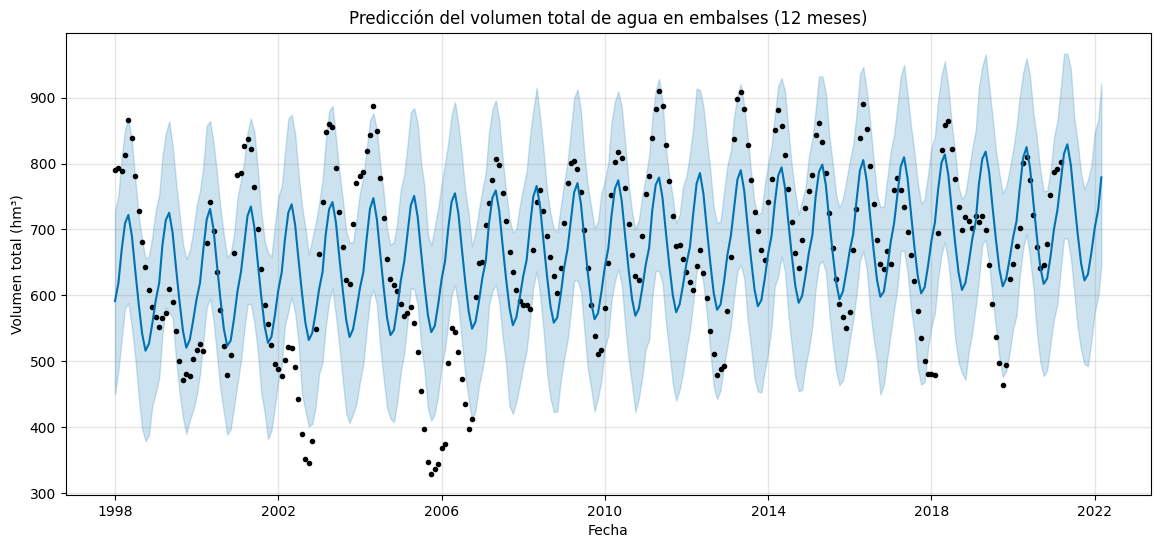

,ds,yhat,yhat_lower,yhat_upper
279,2021-04-01,814.863498,686.714207,966.254734
280,2021-05-01,829.163416,685.821353,966.459948
281,2021-06-01,797.783382,657.464536,943.456621
282,2021-07-01,745.625612,605.715715,870.887914
283,2021-08-01,694.237030,551.689180,832.807818
284,2021-09-01,648.420802,517.211306,785.086319
285,2021-10-01,622.781894,495.812652,760.910114
286,2021-11-01,632.052888,492.823719,774.883783
287,2021-12-01,663.834368,528.596789,796.504391
288,2022-01-01,702.537303,574.819775,846.794027


In [82]:

# 1. IMPORTACIONES

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet



# 2. CARGA DEL DATAFRAME

df = df_final.copy()



# 3. PREPARACIÓN DE DATOS PARA PROPHET

# Diccionario para convertir meses a número
meses_dict = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}

# Convertir mes a número
df['mes_num'] = df['mes'].map(meses_dict)

# Crear columna de fecha (ds)
df['ds'] = pd.to_datetime(
    df['año'].astype(str) + "-" +
    df['mes_num'].astype(str) + "-01"
)

# Convertir TOTAL a float
df['y'] = df['TOTAL'].str.replace(',', '.').astype(float)

# Dataset base para Prophet
df_prophet = df[['ds', 'y']].sort_values('ds').reset_index(drop=True)


# 4. LIMPIEZA DE DATOS Y ANOMALÍAS

# Eliminar valores nulos y ceros para mejorar la previsión
df_prophet = df_prophet.dropna()
df_prophet = df_prophet[df_prophet['y'] > 0]


# 5. CREACIÓN Y ENTRENAMIENTO DEL MODELO

model = Prophet()
model.fit(df_prophet)


# 6. GENERACIÓN DE FECHAS FUTURAS (12 MESES)

future_dates = model.make_future_dataframe(
    periods=12,
    freq='MS'  # Inicio de mes
)



# 7. PREDICCIÓN

predictions = model.predict(future_dates)



# 8. VISUALIZACIÓN DE RESULTADOS

fig, ax = plt.subplots(figsize=(14, 6))
model.plot(predictions, ax=ax)

ax.set_title("Predicción del volumen total de agua en embalses (12 meses)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Volumen total (hm³)")

plt.show()



# 9. MOSTRAR SOLO LAS PREDICCIONES FUTURAS

predicciones_futuras = predictions[
    predictions['ds'] > df_prophet['ds'].max()
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

predicciones_futuras



In [95]:
# PREGUNTA 1: Embalse con mayor diferencia entre máximo y mínimo

import pandas as pd # Importaciones necesarias

# Cargar dataset pivotado (embalses en columnas)
ruta_dataset = "/content/dive/MyDrive/dataset_embalses_final.csv"
df_pivot = pd.read_csv(ruta_dataset, sep=";", encoding="utf-8-sig")

# Columnas de embalses
columnas_embalses = df_pivot.columns.difference(['año', 'mes', 'TOTAL'])

# Convertir valores a float
df_embalses_float = df_pivot[columnas_embalses].replace(',', '.', regex=True).astype(float)

# Calcular diferencia del máximo al mínimo por cada embalse
rango_embalses = df_embalses_float.max() - df_embalses_float.min()

# Embalse con mayor diferencia
embalse_max_diferencia = rango_embalses.idxmax()
valor_max_diferencia = rango_embalses.max()

print(f"El embalse con mayor diferencia entre máximo y mínimo es '{embalse_max_diferencia}' con una diferencia de {valor_max_diferencia:.2f} hm³.")



El embalse con mayor diferencia entre máximo y mínimo (ignorando ceros) es 'ElAtazar' con una diferencia de 275.66 hm³.


In [92]:
# PREGUNTA 2: Detectar sequías por embalse

import pandas as pd

# Cargar dataset pivotado
ruta_dataset = "/content/dive/MyDrive/dataset_embalses_final.csv"
df_pivot = pd.read_csv(ruta_dataset, sep=";", encoding="utf-8-sig")

# Columnas de embalses
columnas_embalses = df_pivot.columns.difference(['año', 'mes', 'TOTAL'])

# Convertir valores a float
df_embalses_float = df_pivot[columnas_embalses].replace(',', '.', regex=True).astype(float)

# Definir umbral de sequía: 30% del promedio de cada embalse
umbrales = df_embalses_float.mean() * 0.3

# DataFrame booleano: True donde hay sequía para luego mostrar las fechas y el mes de las filas con valor True
sequias = df_embalses_float.lt(umbrales)

# Crear DataFrame con años, meses y sequías
df_sequia = df_pivot[['año', 'mes']].copy()
for embalse in columnas_embalses:
    df_sequia[embalse + '_sequía'] = sequias[embalse]

# Mostrar fechas de sequía para cada embalse
for embalse in columnas_embalses:
    fechas = df_sequia[df_sequia[embalse + '_sequía']][['año', 'mes']]
    print(f"\nEmbalse: {embalse} → meses con sequía:")
    print(fechas.to_string(index=False))



Embalse: ElAtazar → meses con sequía:
Empty DataFrame
Columns: [año, mes]
Index: []

Embalse: ElVado → meses con sequía:
 año        mes
1999 Septiembre
2004     Agosto
2004 Septiembre
2005      Junio
2005      Julio
2005     Agosto
2005 Septiembre
2006 Septiembre
2009 Septiembre
2009    Octubre
2009  Noviembre
2015    Octubre
2015  Diciembre
2017    Octubre
2017  Noviembre

Embalse: ElVillar → meses con sequía:
 año   mes
2005 Abril
2005  Mayo
2006 Marzo
2006 Abril
2006  Mayo
2006 Junio
2006 Julio
2007 Junio
2007 Julio

Embalse: LaAcena → meses con sequía:
 año        mes
1999     Agosto
1999 Septiembre
1999    Octubre
2002     Agosto
2019 Septiembre
2019    Octubre
2019  Noviembre

Embalse: LaJorosa → meses con sequía:
 año        mes
2002 Septiembre
2019    Octubre

Embalse: LaPinilla → meses con sequía:
Empty DataFrame
Columns: [año, mes]
Index: []

Embalse: LosMorales → meses con sequía:
 año        mes
2005  Noviembre
2005  Diciembre
2006      Enero
2006    Febrero
2009 Septiemb

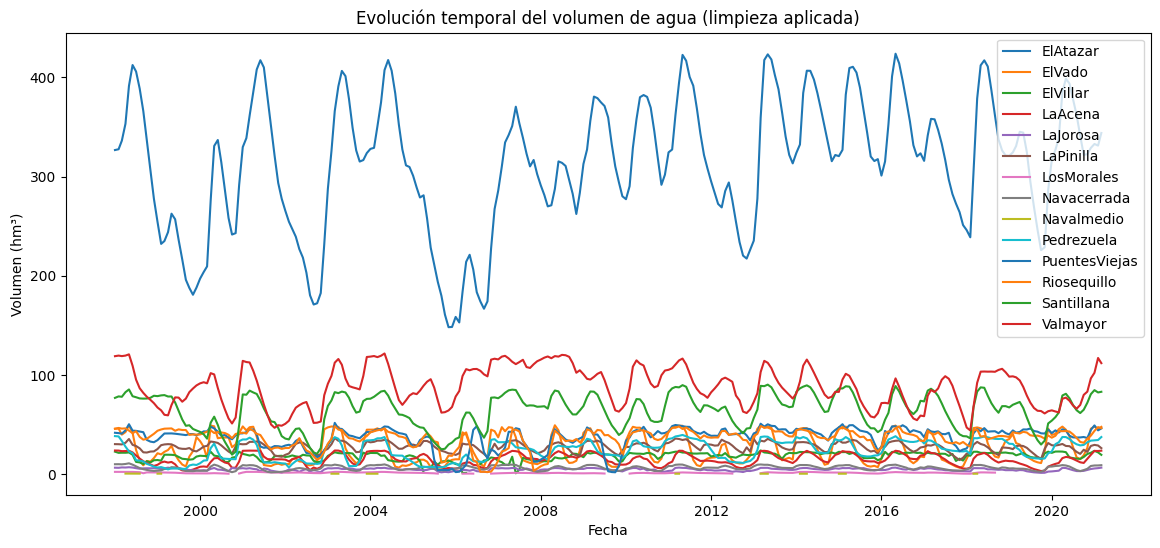

In [97]:
# ESTADÍSTICA 1: Evolución temporal de cada embalse

# Función de limpieza de valores bajos o nulos
def limpiar_valores_extremos(df_embalses):
    """Convierte a float y elimina valores cercanos a 0."""
    df_float = df_embalses.replace(',', '.', regex=True).astype(float)

    # Reemplazar valores menores o iguales a 0.5 hm³ por NaN
    df_float[df_float <= 0.5] = float('nan')
    return df_float

import pandas as pd
import matplotlib.pyplot as plt

ruta_dataset = "/content/dive/MyDrive/dataset_embalses_final.csv"
df_pivot = pd.read_csv(ruta_dataset, sep=";", encoding="utf-8-sig")
columnas_embalses = df_pivot.columns.difference(['año','mes','TOTAL'])

# Limpiar datos
def limpiar_valores_extremos(df_embalses):
    df_float = df_embalses.replace(',', '.', regex=True).astype(float)
    df_float[df_float <= 0.5] = float('nan')
    return df_float

df_embalses_float = limpiar_valores_extremos(df_pivot[columnas_embalses])

# Crear fecha
meses_dict = {
    "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
    "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
}
df_pivot['mes_num'] = df_pivot['mes'].map(meses_dict)
df_pivot['fecha'] = pd.to_datetime(df_pivot['año'].astype(str) + '-' + df_pivot['mes_num'].astype(str) + '-01')

# Plot
plt.figure(figsize=(14,6))
for embalse in columnas_embalses:
    plt.plot(df_pivot['fecha'], df_embalses_float[embalse], label=embalse)

plt.title("Evolución temporal del volumen de agua (limpieza aplicada)")
plt.xlabel("Fecha")
plt.ylabel("Volumen (hm³)")
plt.legend()
plt.show()



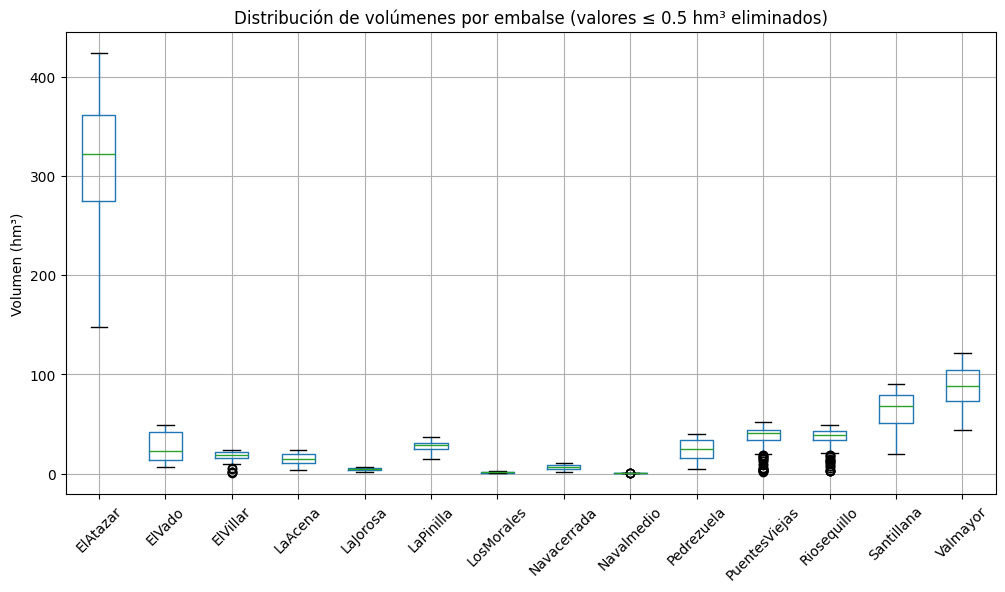

In [100]:

# ESTADÍSTICA 2: Boxplot de volúmenes por embalse

import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset pivotado
ruta_dataset = "/content/dive/MyDrive/dataset_embalses_final.csv"
df_pivot = pd.read_csv(ruta_dataset, sep=";", encoding="utf-8-sig")

# Columnas de embalses
columnas_embalses = df_pivot.columns.difference(['año', 'mes', 'TOTAL'])

# Función para limpiar valores bajos o nulos
def limpiar_valores_extremos(df_embalses, umbral=0.5):
    """
    Convierte a float y reemplaza por NaN todos los valores <= umbral.
    Esto asegura que no se consideren para estadísticas o gráficos.
    """
    df_float = df_embalses.replace(',', '.', regex=True).astype(float)
    df_float[df_float <= umbral] = float('nan')
    return df_float

# Aplicar limpieza
df_embalses_float = limpiar_valores_extremos(df_pivot[columnas_embalses])

# Boxplot
plt.figure(figsize=(12,6))
df_embalses_float.boxplot()
plt.title("Distribución de volúmenes por embalse (valores ≤ 0.5 hm³ eliminados)")
plt.ylabel("Volumen (hm³)")
plt.xticks(rotation=45)
plt.show()



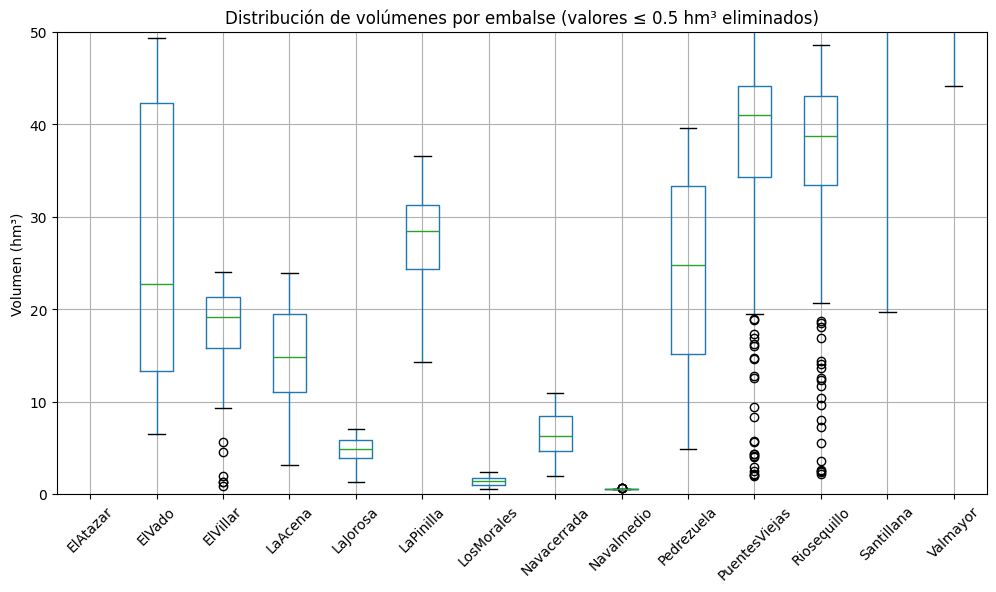

In [117]:
# ESTADÍSTICA 2: Boxplot sin compactar

import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset pivotado
ruta_dataset = "/content/dive/MyDrive/dataset_embalses_final.csv"
df_pivot = pd.read_csv(ruta_dataset, sep=";", encoding="utf-8-sig")

# Columnas de embalses
columnas_embalses = df_pivot.columns.difference(['año', 'mes', 'TOTAL'])

# Función para limpiar valores bajos o nulos
def limpiar_valores_extremos(df_embalses, umbral=0.5):
    """
    Convierte a float y reemplaza por NaN todos los valores <= umbral.
    Esto asegura que no se consideren para estadísticas o gráficos.
    """
    df_float = df_embalses.replace(',', '.', regex=True).astype(float)
    df_float[df_float <= umbral] = float('nan')
    return df_float

# Aplicar limpieza
df_embalses_float = limpiar_valores_extremos(df_pivot[columnas_embalses])

# Boxplot
plt.figure(figsize=(12,6))
df_embalses_float.boxplot()
plt.title("Distribución de volúmenes por embalse (valores ≤ 0.5 hm³ eliminados)")
plt.ylabel("Volumen (hm³)")
plt.xticks(rotation=45)

# Limitar eje Y, se recomienda variar el valor
plt.ylim(0, 50)

plt.show()


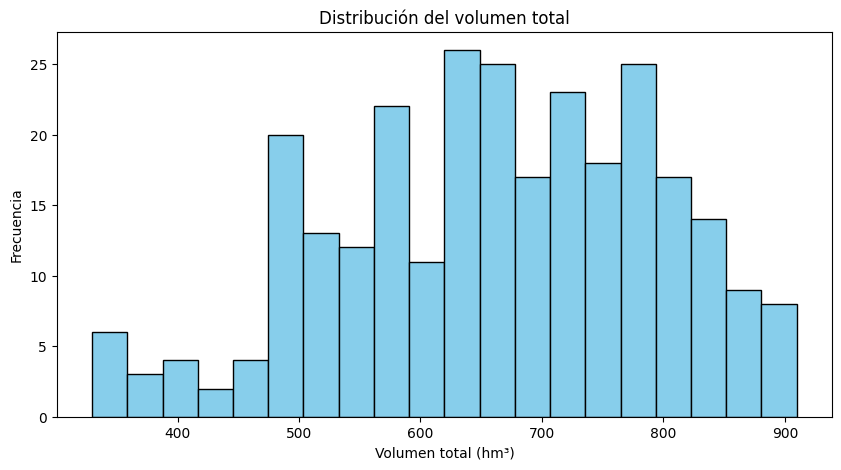

In [ ]:
# ESTADÍSTICA 3: Histograma de volúmenes totales

# Histograma con función específica de limpieza de valores inferiores

import pandas as pd
import matplotlib.pyplot as plt

ruta_dataset = "/content/dive/MyDrive/dataset_embalses_final.csv"
df_pivot = pd.read_csv(ruta_dataset, sep=";", encoding="utf-8-sig")

# Convertir TOTAL a float
df_pivot['TOTAL_float'] = df_pivot['TOTAL'].str.replace(',', '.').astype(float)

# Limpiar valores menores que definamos
df_pivot['TOTAL_float'] = df_pivot['TOTAL_float'].apply(lambda x: x if x >= 250 else float('nan'))

# Histograma
plt.figure(figsize=(10,5))
plt.hist(df_pivot['TOTAL_float'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title("Distribución del volumen total")
plt.xlabel("Volumen total (hm³)")
plt.ylabel("Frecuencia")
plt.show()



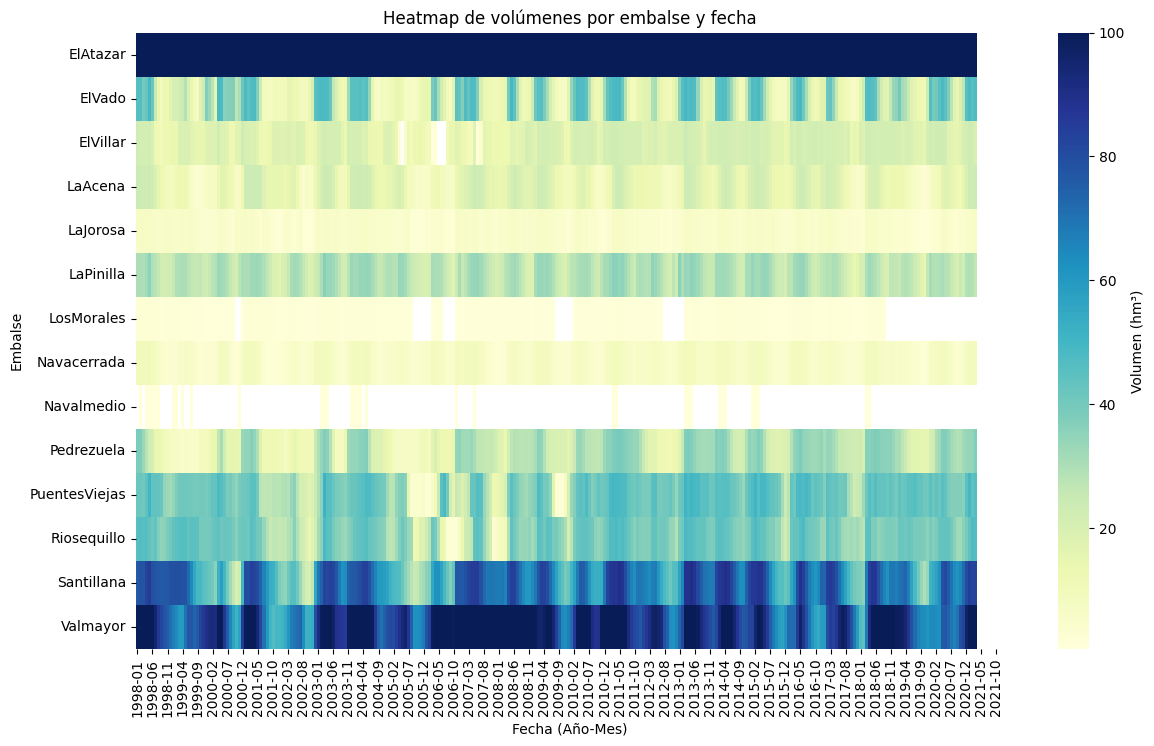

In [116]:
# ESTADÍSTICA 4: HETMAP O MAPA DE CALOR POR EMBALSE Y MES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
ruta_dataset = "/content/dive/MyDrive/dataset_embalses_final.csv"
df_pivot = pd.read_csv(ruta_dataset, sep=";", encoding="utf-8-sig")
columnas_embalses = df_pivot.columns.difference(['año','mes','TOTAL'])

# Limpiar valores bajos
def limpiar_valores_extremos(df_embalses, umbral_min=0.5, umbral_max=100):
    df_float = df_embalses.replace(',', '.', regex=True).astype(float)
    df_float[df_float <= umbral_min] = float('nan')  # eliminar valores muy bajos
    df_float[df_float > umbral_max] = umbral_max     # limitar valores muy altos
    return df_float

df_embalses_float = limpiar_valores_extremos(df_pivot[columnas_embalses])

# Crear pivot tabla para heatmap
df_heatmap = df_embalses_float.copy()
df_heatmap['fecha'] = pd.to_datetime(
    df_pivot['año'].astype(str) + '-' +
    df_pivot['mes'].map({
        "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
        "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
    }).astype(str) + '-01',
    format="%Y-%m-%d"
)

# Convertir el índice a string YYYY-MM para eliminar hora
df_heatmap = df_heatmap.set_index(df_heatmap['fecha'].dt.strftime('%Y-%m'))

plt.figure(figsize=(14,8))
sns.heatmap(df_heatmap[columnas_embalses].T, cmap='YlGnBu', cbar_kws={'label': 'Volumen (hm³)'})
plt.title("Heatmap de volúmenes por embalse y fecha")
plt.xlabel("Fecha (Año-Mes)")
plt.ylabel("Embalse")
plt.show()



/tmp/ipython-input-529689839.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_pivot['TOTAL_float'][df_pivot['TOTAL_float'] <= 0.5] = float('nan')
/tmp/ipython-input-529689839.py:5: SettingWithCopyWarning: 
A value is trying to be set o

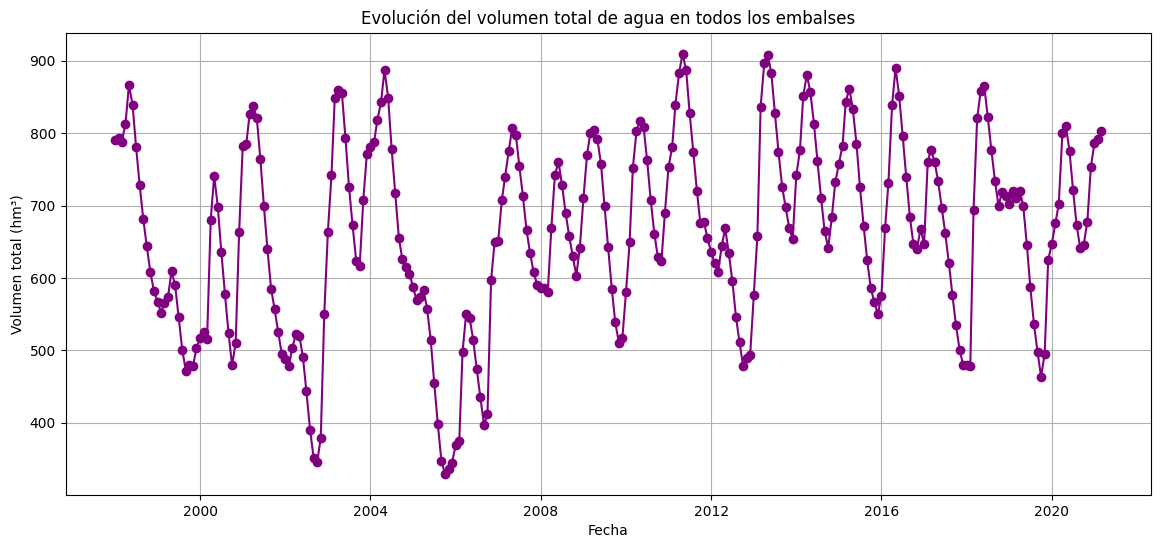

In [119]:
# Convertir TOTAL a float
df_pivot['TOTAL_float'] = df_pivot['TOTAL'].str.replace(',', '.').astype(float)

# Limpiar valores menores a 0.5 hm³
df_pivot['TOTAL_float'][df_pivot['TOTAL_float'] <= 0.5] = float('nan')

# Crear fecha
df_pivot['fecha'] = pd.to_datetime(df_pivot['año'].astype(str) + '-' + df_pivot['mes'].map({
    "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
    "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
}).astype(str) + '-01')

# Plot evolución total
plt.figure(figsize=(14,6))
plt.plot(df_pivot['fecha'], df_pivot['TOTAL_float'], color='purple', marker='o')
plt.title("Evolución del volumen total de agua en todos los embalses")
plt.xlabel("Fecha")
plt.ylabel("Volumen total (hm³)")
plt.grid(True)
plt.show()
